In [ ]:
%%capture
!pip install pandas scikit-learn keras tensorflow
!pip install transformers torch
!pip install datasets


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.current_device())


True
0


In [ ]:
import pandas as pd
import numpy as np
import os, re
import matplotlib.pyplot as plt
import seaborn as sns

#Tamil

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


SVM with Combined Features Performance on Validation set
              precision    recall  f1-score   support

          AI       0.96      0.90      0.93        49
       HUMAN       0.86      0.94      0.90        32

    accuracy                           0.91        81
   macro avg       0.91      0.92      0.91        81
weighted avg       0.92      0.91      0.91        81

SVM with Combined Model Performance on Test set
              precision    recall  f1-score   support

          AI       0.76      0.79      0.78        48
       HUMAN       0.80      0.77      0.78        52

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.78      0.78      0.78       100



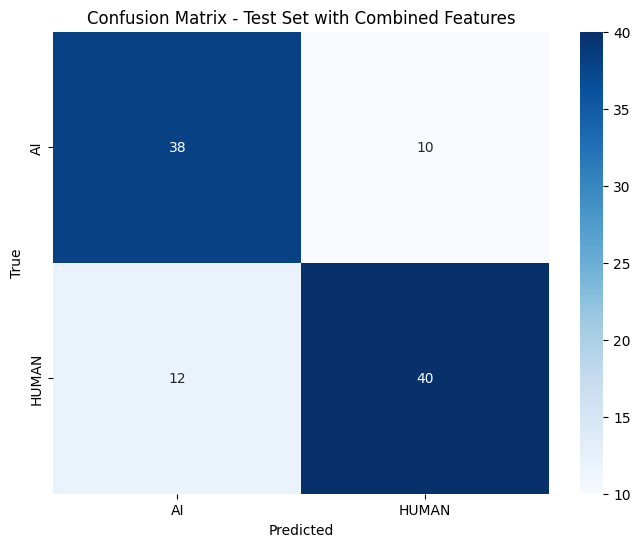

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')

train_data = pd.read_csv('tam_train.csv')
test_data = pd.read_csv('tam_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_data['DATA'])
X_train_tfidf = vectorizer.transform(train_data['DATA']).toarray()

X_train_combined = np.hstack([X_train_tfidf, X_train_word2vec])

scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_combined)

X_train_final, X_val_combined, y_train, y_val = train_test_split(X_train_combined, train_data['LABEL'], test_size=0.1, random_state=42)

svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train_final, y_train)

y_pred_combined = svm_model.predict(X_val_combined)

y_pred_combined_labels = label_encoder.inverse_transform(y_pred_combined)

y_val_labels = label_encoder.inverse_transform(y_val)

print("SVM with Combined Features Performance on Validation set")
print(classification_report(y_val_labels, y_pred_combined_labels, target_names=label_encoder.classes_))

X_test_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in test_data['DATA']])
X_test_tfidf = vectorizer.transform(test_data['DATA']).toarray()
X_test_combined = np.hstack([X_test_tfidf, X_test_word2vec])
X_test_combined = scaler.transform(X_test_combined)

svm_predictions_combined = svm_model.predict(X_test_combined)

svm_predictions_combined_labels = label_encoder.inverse_transform(svm_predictions_combined)

test_data['LABEL_PRED'] = svm_predictions_combined_labels

test_data[["ID", "LABEL_PRED"]].to_csv('prediction_tam_svm.csv', index=False)

report_combined = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("SVM with Combined Model Performance on Test set")
print(report_combined)

conf_matrix_test_combined = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_combined, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with Combined Features")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'sigmoid'}
Best SVM Model Performance on Validation set
              precision    recall  f1-score   support

          AI       0.98      0.94      0.96        49
       HUMAN       0.91      0.97      0.94        32

    accuracy                           0.95        81
   macro avg       0.95      0.95      0.95        81
weighted avg       0.95      0.95      0.95        81

Best SVM Model Performance on Test set
              precision    recall  f1-score   support

          AI       0.73      0.77      0.75        48
       HUMAN       0.78      0.73      0.75        52

    accuracy                           0.75       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.75      0.75      0.75       100



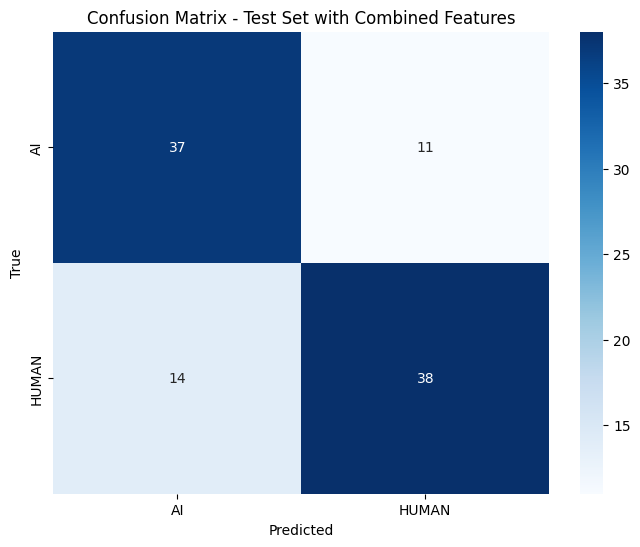

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')

train_data = pd.read_csv('tam_train.csv')
test_data = pd.read_csv('tam_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_data['DATA'])
X_train_tfidf = vectorizer.transform(train_data['DATA']).toarray()

X_train_combined = np.hstack([X_train_tfidf, X_train_word2vec])

scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_combined)

X_train_final, X_val_combined, y_train, y_val = train_test_split(X_train_combined, train_data['LABEL'], test_size=0.1, random_state=42)

param_grid = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_final, y_train)

print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

y_pred_combined = best_model.predict(X_val_combined)

y_pred_combined_labels = label_encoder.inverse_transform(y_pred_combined)

y_val_labels = label_encoder.inverse_transform(y_val)

print("Best SVM Model Performance on Validation set")
print(classification_report(y_val_labels, y_pred_combined_labels, target_names=label_encoder.classes_))

X_test_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in test_data['DATA']])
X_test_tfidf = vectorizer.transform(test_data['DATA']).toarray()
X_test_combined = np.hstack([X_test_tfidf, X_test_word2vec])
X_test_combined = scaler.transform(X_test_combined)

svm_predictions_combined = best_model.predict(X_test_combined)

svm_predictions_combined_labels = label_encoder.inverse_transform(svm_predictions_combined)

test_data['LABEL_PRED'] = svm_predictions_combined_labels

test_data[["ID", "LABEL_PRED"]].to_csv('prediction.csv', index=False)

report_combined = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("Best SVM Model Performance on Test set")
print(report_combined)

conf_matrix_test_combined = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_combined, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with Combined Features")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 277ms/step - accuracy: 0.5342 - loss: 0.6940 - val_accuracy: 0.6420 - val_loss: 0.6820
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - accuracy: 0.6470 - loss: 0.6721 - val_accuracy: 0.6420 - val_loss: 0.6649
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.6929 - loss: 0.6163 - val_accuracy: 0.6049 - val_loss: 0.6674
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.6835 - loss: 0.6037 - val_accuracy: 0.6667 - val_loss: 0.6206
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.7224 - loss: 0.5740 - val_accuracy: 0.6914 - val_loss: 0.6164
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.6917 - loss: 0.5783 - val_accuracy: 0.6543 - val_loss: 0.6339
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7411 - loss: 0.5499 - val_accuracy: 0.6420 - val_loss: 0.6156
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.6922 - loss: 0.6117 - val_accuracy: 0.617

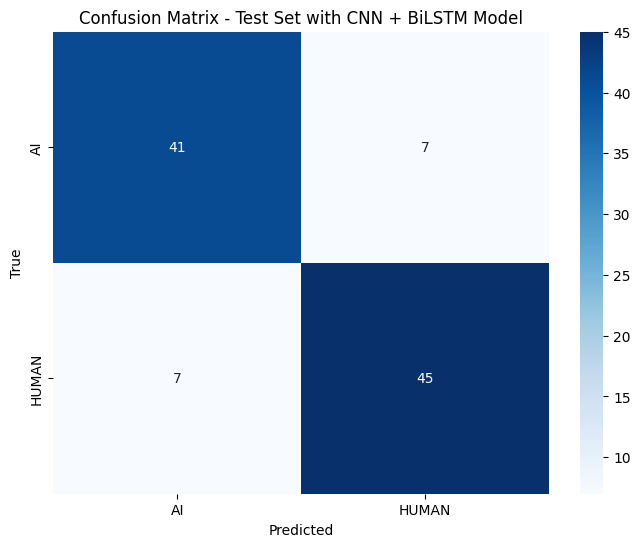

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('punkt')

train_data = pd.read_csv('tam_train.csv')
test_data = pd.read_csv('tam_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

tokenizer = keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(train_data['DATA'])
X_train_seq = tokenizer.texts_to_sequences(train_data['DATA'])
X_train_padded = pad_sequences(X_train_seq, maxlen=100)

y_train = train_data['LABEL'].values

X_train_final, X_val_seq, y_train, y_val = train_test_split(X_train_padded, y_train, test_size=0.1, random_state=42)

model = Sequential()

model.add(layers.Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(X_train_padded.shape[1], 1)))
model.add(layers.MaxPooling1D(pool_size=2))

model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))
model.add(layers.Dropout(0.5))

model.add(layers.GlobalAveragePooling1D())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(label_encoder.classes_), activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train_final, y_train, epochs=10, batch_size=32, validation_data=(X_val_seq, y_val))

y_pred_val = model.predict(X_val_seq)
y_pred_val_labels = np.argmax(y_pred_val, axis=1)

y_val_labels = label_encoder.inverse_transform(y_val)
y_pred_val_labels = label_encoder.inverse_transform(y_pred_val_labels)

print("CNN + BiLSTM Model Performance on Validation set")
print(classification_report(y_val_labels, y_pred_val_labels, target_names=label_encoder.classes_))

X_test_seq = tokenizer.texts_to_sequences(test_data['DATA'])
X_test_padded = pad_sequences(X_test_seq, maxlen=100)

y_pred_test = model.predict(X_test_padded)
y_pred_test_labels = np.argmax(y_pred_test, axis=1)
y_pred_test_labels = label_encoder.inverse_transform(y_pred_test_labels)

test_data['LABEL_PRED'] = y_pred_test_labels
test_data[["ID", "LABEL_PRED"]].to_csv('prediction.csv', index=False)

report_test = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("CNN + BiLSTM Model Performance on Test set")
print(report_test)

conf_matrix_test = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with CNN + BiLSTM Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5669 - loss: 0.6900 - val_accuracy: 0.8148 - val_loss: 0.6659
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9823 - loss: 0.6170 - val_accuracy: 0.8889 - val_loss: 0.5287
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9975 - loss: 0.3809 - val_accuracy: 0.9012 - val_loss: 0.2941
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.1050 - val_accuracy: 0.9198 - val_loss: 0.2049
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0221 - val_accuracy: 0.9074 - val_loss: 0.1988
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 0.9136 - val_loss: 0.1994
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.9074 - val_loss: 0.2027
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.9074 - val_loss: 0.2063
Ep

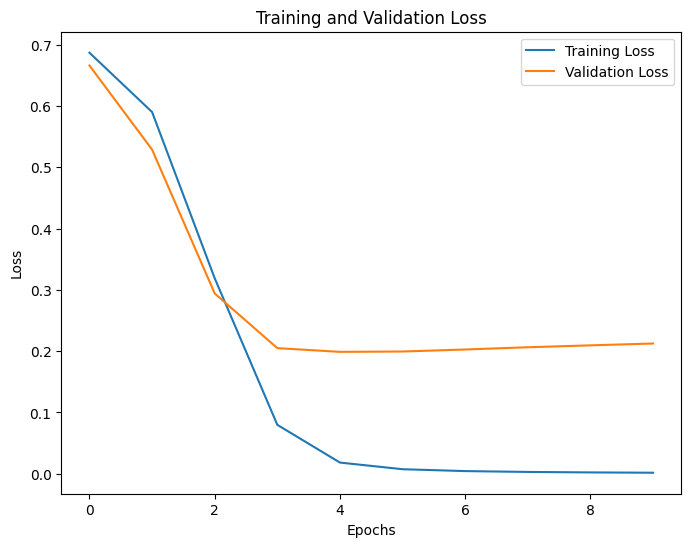

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
MLP Model Performance on Validation set:
              precision    recall  f1-score   support

          AI       0.89      0.94      0.92        86
       HUMAN       0.93      0.87      0.90        76

    accuracy                           0.91       162
   macro avg       0.91      0.91      0.91       162
weighted avg       0.91      0.91      0.91       162

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
MLP Model Performance on Test set:
              precision    recall  f1-score   support

          AI       0.70      0.73      0.71        48
       HUMAN       0.74      0.71      0.73        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

train_data = pd.read_csv('tam_train.csv')
test_data = pd.read_csv('tam_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X = train_data['DATA']
y = train_data['LABEL']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


vectorizer.fit(X_train)
X_train_vect = vectorizer.transform(X_train).toarray()
X_val_vect = vectorizer.transform(X_val).toarray()

mlp_model = keras.Sequential([
    layers.InputLayer(input_shape=(X_train_vect.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = mlp_model.fit(X_train_vect, y_train, epochs=10, batch_size=32, validation_data=(X_val_vect, y_val))

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

y_pred_mlp = (mlp_model.predict(X_val_vect) > 0.5).astype("int32")
print("MLP Model Performance on Validation set:")
print(classification_report(y_val, y_pred_mlp, target_names=label_encoder.classes_))


X_test = test_data['DATA']
X_test_vect = vectorizer.transform(X_test).toarray()

mlp_predictions = (mlp_model.predict(X_test_vect) > 0.5).astype("int32")
test_data['LABEL_PRED'] = label_encoder.inverse_transform(mlp_predictions.flatten())

test_data[["ID", "LABEL_PRED"]].to_csv('prediction.csv', index=False)

report = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("MLP Model Performance on Test set:")
print(report)

conf_matrix_test = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
!pip install scikit-learn==1.5.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 39.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Random Forest Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.93      0.82      0.87        49
       HUMAN       0.76      0.91      0.83        32

    accuracy                           0.85        81
   macro avg       0.85      0.86      0.85        81
weighted avg       0.86      0.85      0.85        81

XGBoost Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.91      0.82      0.86        49
       HUMAN       0.76      0.88      0.81        32

    accuracy                           0.84        81
   macro avg       0.83      0.85      0.84        81
weighted avg       0.85      0.84      0.84        81

Ensemble (RF + XGBoost) Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.93      0.82      0.87        49
       HUMAN       0.76      0.91      0.83        32

    accuracy                           0.85

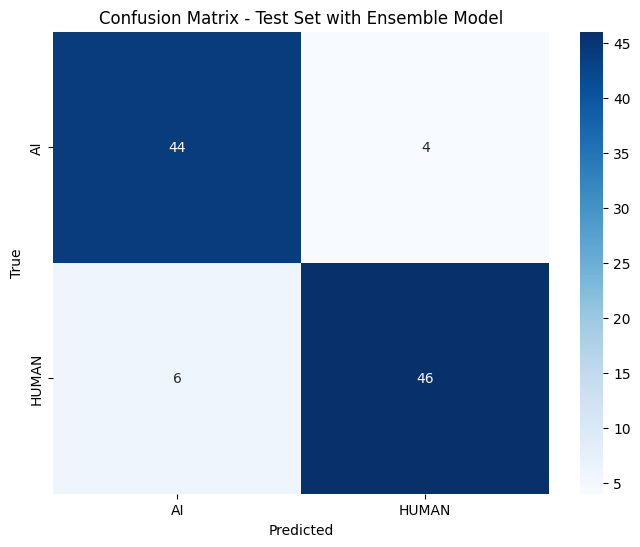

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('punkt_tab')

train_data = pd.read_csv('tam_train.csv')
test_data = pd.read_csv('tam_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_data['DATA'])
X_train_tfidf = vectorizer.transform(train_data['DATA']).toarray()

X_train_combined = np.hstack([X_train_tfidf, X_train_word2vec])

scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_combined)

X_train_final, X_val_combined, y_train, y_val = train_test_split(X_train_combined, train_data['LABEL'], test_size=0.1, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train_final, y_train)

ensemble_model = VotingClassifier(estimators=[('rf', rf_model), ('xgb', xgb_model)], voting='soft')
ensemble_model.fit(X_train_final, y_train)

y_val_labels = label_encoder.inverse_transform(y_val)

y_pred_rf = rf_model.predict(X_val_combined)
y_pred_rf_labels = label_encoder.inverse_transform(y_pred_rf)

y_pred_xgb = xgb_model.predict(X_val_combined)
y_pred_xgb_labels = label_encoder.inverse_transform(y_pred_xgb)

y_pred_ensemble = ensemble_model.predict(X_val_combined)
y_pred_ensemble_labels = label_encoder.inverse_transform(y_pred_ensemble)

print("Random Forest Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_rf_labels, target_names=label_encoder.classes_))

print("XGBoost Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_xgb_labels, target_names=label_encoder.classes_))

print("Ensemble Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_ensemble_labels, target_names=label_encoder.classes_))

X_test_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in test_data['DATA']])

X_test_tfidf = vectorizer.transform(test_data['DATA']).toarray()

X_test_combined = np.hstack([X_test_tfidf, X_test_word2vec])
X_test_combined = scaler.transform(X_test_combined)

predictions_ensemble = ensemble_model.predict(X_test_combined)
predictions_ensemble_labels = label_encoder.inverse_transform(predictions_ensemble)

test_data['LABEL_PRED'] = predictions_ensemble_labels
test_data[["ID", "LABEL_PRED"]].to_csv('prediction_tam_ensemble.csv', index=False)

report_ensemble = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("Ensemble (RF + XGBoost) Performance on Test Set")
print(report_ensemble)

conf_matrix_test_ensemble = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_ensemble, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with Ensemble Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()




---
#Malayalam


In [ ]:
#IndicBERT RUN-1
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch

os.environ["WANDB_MODE"] = "disabled"

train_data = pd.read_csv("mal_train.csv")
test_data = pd.read_csv("mal_test.csv")

def preprocess_text(text):
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_data["DATA"] = train_data["DATA"].apply(preprocess_text)
test_data["DATA"] = test_data["DATA"].apply(preprocess_text)

train_data.dropna(subset=["DATA", "LABEL"], inplace=True)

label_encoder = LabelEncoder()
train_data["LABEL"] = label_encoder.fit_transform(train_data["LABEL"])

train_data = train_data.rename(columns={"DATA": "text", "LABEL": "label"})
test_data = test_data.rename(columns={"DATA": "text"})
train_dataset = Dataset.from_pandas(train_data)
test_dataset = Dataset.from_pandas(test_data)

model_name = "ai4bharat/indic-bert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_encoder.classes_))

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text", "ID"])
test_dataset = test_dataset.remove_columns(["text", "ID"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=False
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = torch.argmax(torch.tensor(pred.predictions), dim=1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
)

trainer.train()

predictions = trainer.predict(test_dataset)

test_data["LABEL_PRED"] = label_encoder.inverse_transform(predictions.predictions.argmax(axis=1))

test_data[["ID", "LABEL_PRED"]].to_csv('prediction.csv', index=False)

report = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print('Model Performance on Test set')
print(report)

conf_matrix_test = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-24-fa60403198fa>:67: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Epoch,Training Loss,Validation Loss
1,0.623100,No log
2,0.485500,No log
3,0.383200,No log
4,0.347400,No log
5,0.146200,No log
6,0.080300,No log
7,0.066600,No log
8,0.040200,No log
9,0.006100,No log
10,0.035500,No log


Model Performance on Test set
              precision    recall  f1-score   support

          AI       0.78      0.73      0.76       100
       HUMAN       0.75      0.80      0.77       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'sigmoid'}
Best SVM Model Performance on Validation set
              precision    recall  f1-score   support

          AI       0.72      0.87      0.79        39
       HUMAN       0.85      0.68      0.76        41

    accuracy                           0.78        80
   macro avg       0.79      0.78      0.77        80
weighted avg       0.79      0.78      0.77        80

Best SVM Model Performance on Test set
              precision    recall  f1-score   support

          AI       0.72      0.63      0.67       100
       HUMAN       0.67      0.76      0.71       100

    accuracy                           0.69       200
   macro avg       0.70      0.70      0.69       200
weighted avg       0.70      0.69      0.69       200



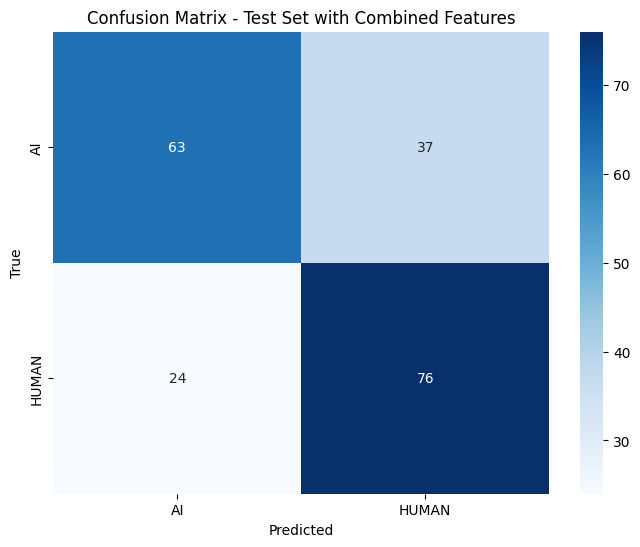

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')

train_data = pd.read_csv('mal_train.csv')
test_data = pd.read_csv('mal_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_data['DATA'])
X_train_tfidf = vectorizer.transform(train_data['DATA']).toarray()

X_train_combined = np.hstack([X_train_tfidf, X_train_word2vec])

scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_combined)

X_train_final, X_val_combined, y_train, y_val = train_test_split(X_train_combined, train_data['LABEL'], test_size=0.1, random_state=42)

param_grid = {
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_final, y_train)

print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

y_pred_combined = best_model.predict(X_val_combined)

y_pred_combined_labels = label_encoder.inverse_transform(y_pred_combined)

y_val_labels = label_encoder.inverse_transform(y_val)

print("Best SVM Model Performance on Validation set")
print(classification_report(y_val_labels, y_pred_combined_labels, target_names=label_encoder.classes_))

X_test_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in test_data['DATA']])
X_test_tfidf = vectorizer.transform(test_data['DATA']).toarray()
X_test_combined = np.hstack([X_test_tfidf, X_test_word2vec])
X_test_combined = scaler.transform(X_test_combined)

svm_predictions_combined = best_model.predict(X_test_combined)

svm_predictions_combined_labels = label_encoder.inverse_transform(svm_predictions_combined)

test_data['LABEL_PRED'] = svm_predictions_combined_labels

test_data[["ID", "LABEL_PRED"]].to_csv('prediction_mal_svm.csv', index=False)

report_combined = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("Best SVM Model Performance on Test set")
print(report_combined)

conf_matrix_test_combined = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_combined, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with Combined Features")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 200ms/step - accuracy: 0.5396 - loss: 0.6789 - val_accuracy: 0.7750 - val_loss: 0.6318
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.6085 - loss: 0.6396 - val_accuracy: 0.7125 - val_loss: 0.6034
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.6292 - loss: 0.6384 - val_accuracy: 0.7750 - val_loss: 0.5606
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.6359 - loss: 0.5998 - val_accuracy: 0.7250 - val_loss: 0.5398
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6955 - loss: 0.5737 - val_accuracy: 0.7250 - val_loss: 0.5118
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6545 - loss: 0.5944 - val_accuracy: 0.7750 - val_loss: 0.5106
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6728 - loss: 0.5547 - val_accuracy: 0.7500 - val_loss: 0.5191
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.6910 - loss: 0.5660 - val_accuracy: 0.787

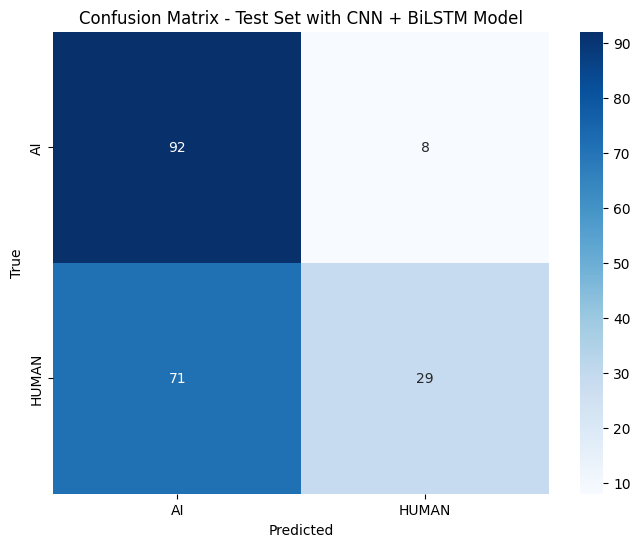

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('punkt')

train_data = pd.read_csv('mal_train.csv')
test_data = pd.read_csv('mal_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

tokenizer = keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(train_data['DATA'])
X_train_seq = tokenizer.texts_to_sequences(train_data['DATA'])
X_train_padded = pad_sequences(X_train_seq, maxlen=100)

y_train = train_data['LABEL'].values

X_train_final, X_val_seq, y_train, y_val = train_test_split(X_train_padded, y_train, test_size=0.1, random_state=42)

model = Sequential()

model.add(layers.Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(X_train_padded.shape[1], 1)))
model.add(layers.MaxPooling1D(pool_size=2))

model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=True)))
model.add(layers.Dropout(0.5))

model.add(layers.GlobalAveragePooling1D())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(label_encoder.classes_), activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train_final, y_train, epochs=15, batch_size=32, validation_data=(X_val_seq, y_val))

y_pred_val = model.predict(X_val_seq)
y_pred_val_labels = np.argmax(y_pred_val, axis=1)

y_val_labels = label_encoder.inverse_transform(y_val)
y_pred_val_labels = label_encoder.inverse_transform(y_pred_val_labels)

print("CNN + BiLSTM Model Performance on Validation set")
print(classification_report(y_val_labels, y_pred_val_labels, target_names=label_encoder.classes_))

X_test_seq = tokenizer.texts_to_sequences(test_data['DATA'])
X_test_padded = pad_sequences(X_test_seq, maxlen=100)

y_pred_test = model.predict(X_test_padded)
y_pred_test_labels = np.argmax(y_pred_test, axis=1)
y_pred_test_labels = label_encoder.inverse_transform(y_pred_test_labels)

test_data['LABEL_PRED'] = y_pred_test_labels
test_data[["ID", "LABEL_PRED"]].to_csv('prediction_mal_cnn_bilstm.csv', index=False)

report_test = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("CNN + BiLSTM Model Performance on Test set")
print(report_test)

conf_matrix_test = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with CNN + BiLSTM Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Random Forest Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.64      0.82      0.72        39
       HUMAN       0.77      0.56      0.65        41

    accuracy                           0.69        80
   macro avg       0.70      0.69      0.68        80
weighted avg       0.70      0.69      0.68        80

XGBoost Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.69      0.79      0.74        39
       HUMAN       0.77      0.66      0.71        41

    accuracy                           0.72        80
   macro avg       0.73      0.73      0.72        80
weighted avg       0.73      0.72      0.72        80

Ensemble (RF + XGBoost) Performance on Validation Set:
              precision    recall  f1-score   support

          AI       0.67      0.79      0.73        39
       HUMAN       0.76      0.63      0.69        41

    accuracy                           0.71

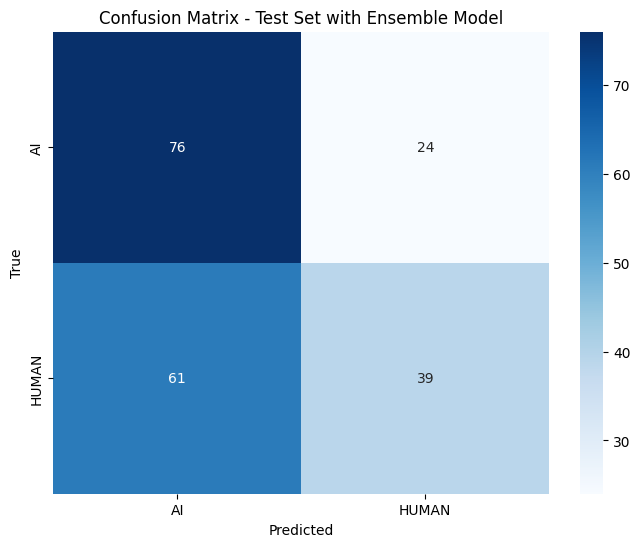

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('punkt_tab')

train_data = pd.read_csv('mal_train.csv')
test_data = pd.read_csv('mal_test.csv')

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_data['DATA'] = train_data['DATA'].apply(preprocess_text)
test_data['DATA'] = test_data['DATA'].apply(preprocess_text)

train_data.dropna(subset=['DATA', 'LABEL'], inplace=True)

label_encoder = LabelEncoder()
train_data['LABEL'] = label_encoder.fit_transform(train_data['LABEL'])

def preprocess_text_for_word2vec(text):
    tokens = word_tokenize(text.lower())
    return tokens

word2vec_model = Word2Vec(sentences=train_data['DATA'].apply(preprocess_text_for_word2vec),
                           vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_embeddings(text, model, vector_size=100):
    tokens = preprocess_text_for_word2vec(text)
    word_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(word_vectors, axis=0)

X_train_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in train_data['DATA']])

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
vectorizer.fit(train_data['DATA'])
X_train_tfidf = vectorizer.transform(train_data['DATA']).toarray()

X_train_combined = np.hstack([X_train_tfidf, X_train_word2vec])

scaler = StandardScaler()
X_train_combined = scaler.fit_transform(X_train_combined)

X_train_final, X_val_combined, y_train, y_val = train_test_split(X_train_combined, train_data['LABEL'], test_size=0.1, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train_final, y_train)

ensemble_model = VotingClassifier(estimators=[('rf', rf_model), ('xgb', xgb_model)], voting='soft')
ensemble_model.fit(X_train_final, y_train)

y_val_labels = label_encoder.inverse_transform(y_val)

y_pred_rf = rf_model.predict(X_val_combined)
y_pred_rf_labels = label_encoder.inverse_transform(y_pred_rf)

y_pred_xgb = xgb_model.predict(X_val_combined)
y_pred_xgb_labels = label_encoder.inverse_transform(y_pred_xgb)

y_pred_ensemble = ensemble_model.predict(X_val_combined)
y_pred_ensemble_labels = label_encoder.inverse_transform(y_pred_ensemble)

print("Random Forest Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_rf_labels, target_names=label_encoder.classes_))

print("XGBoost Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_xgb_labels, target_names=label_encoder.classes_))

print("Ensemble (RF + XGBoost) Performance on Validation Set:")
print(classification_report(y_val_labels, y_pred_ensemble_labels, target_names=label_encoder.classes_))

X_test_word2vec = np.array([get_word2vec_embeddings(text, word2vec_model) for text in test_data['DATA']])

X_test_tfidf = vectorizer.transform(test_data['DATA']).toarray()

X_test_combined = np.hstack([X_test_tfidf, X_test_word2vec])
X_test_combined = scaler.transform(X_test_combined)

predictions_ensemble = ensemble_model.predict(X_test_combined)
predictions_ensemble_labels = label_encoder.inverse_transform(predictions_ensemble)

test_data['LABEL_PRED'] = predictions_ensemble_labels
test_data[["ID", "LABEL_PRED"]].to_csv('prediction_mal_ensemble.csv', index=False)

report_ensemble = classification_report(test_data["LABEL"], test_data["LABEL_PRED"])
print("Ensemble Performance on Test Set")
print(report_ensemble)

conf_matrix_test_ensemble = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test_ensemble, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set with Ensemble Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()